# Minimum Risk Portfolios — CRSP Backtest

Builds fully-invested, long-only **minimum risk** portfolios on the CRSP universe and
measures their out-of-sample performance.

The equally weighted and value weighted benchmarks that the project requires for
comparison are produced separately; this notebook covers the minimum risk portfolio only.

Covariance comes from the **single-factor model** of Homework 3, so the minimum-risk
problem has the analytic solution of Homework 4, Exercise 2.

Section headings below map to the implementation steps on page 2 of `project.pdf`.

| Step | Where |
|---|---|
| (a) choose test period, `T`, `n` | §3 |
| (b) estimate at the start date, record the next month | §4 |
| (c) repeat to the end date | §5 |
| (d) summary statistics and cumulative return charts | §6, §7 |

## 1. Setup

In [1]:
import os, sys
# Run from the project root whether the kernel starts there or in analysis/.
if not os.path.exists("data") and os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from estimation import estimate_single_factor
from min_risk import min_risk, min_risk_closed_form
from backtest import select_universe, rolling_backtest, summarize
from project_data import download_crsp, data_quality_report

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

python 3.13.9 | numpy 2.3.5 | pandas 2.3.3


## 2. Load and validate the data

Data comes through `project_data.download_crsp()`, the same loader the rest of the team
uses, so every notebook in the project reads an identical panel. It returns the cached
`data/crsp_msf_v2.parquet` if present, and otherwise downloads it from WRDS — which is how
a peer reviewer without the file reproduces our results.

The second input is `data/MktRf.csv` (Kenneth French), for the market excess return and
the risk-free rate.

Two things to be careful about.

**Units.** CRSP returns are decimals; French's data is in *percentage points*, so `Mkt-RF`
and `RF` are divided by 100. `project.pdf` flags this explicitly on page 1.

**Date keys.** `mthcaldt` is the last *trading* day of the month, not the last calendar day
(1994-12-31 fell on a Saturday, so the record is dated 1994-12-30). Everything is therefore
keyed on the integer `yyyymm`, which joins cleanly with French's data.

In [2]:
if os.path.exists("data/crsp_msf_v2.parquet"):
    raw = download_crsp()
else:
    import wrds
    raw = download_crsp(wrds.Connection())

ff = pd.read_csv("data/MktRf.csv", index_col=0)
ff.index.name = "yyyymm"
mkt_all = ff["Mkt-RF"] / 100.0      # percentage points -> decimals
rf_all = ff["RF"] / 100.0
print(f"MktRf: {ff.index.min()}-{ff.index.max()}")

data_quality_report(raw).to_frame("value")

CRSP: 2,179,752 rows, 199001-202512, 18,905 permno


MktRf: 192607-202607


### Exchange filter

`project_data.download_crsp` already restricts the sample to US common stock **in the
download SQL** (`sharetype='NS'`, `securitytype='EQTY'`, `securitysubtype='COM'`,
`usincflg='Y'`, `issuertype in ('ACOR','CORP')`), so ETFs, funds and ADRs are not in the
file at all. Those columns are not in the extract because they were filter conditions
rather than selected fields — their absence is not a gap in the screen.

What remains to do here is the exchange filter: keep NYSE / NYSE American / Nasdaq
(`N`, `A`, `Q`). This matches `analysis/comparison.ipynb`, so the universes agree.

In [3]:
KEEP_EXCH = ["N", "A", "Q"]
crsp = raw[raw.primaryexch.isin(KEEP_EXCH)]
print(f"exchange filter: dropped {len(raw) - len(crsp):,} of {len(raw):,} rows "
      f"({(len(raw) - len(crsp)) / len(raw):.2%})")
print("\ndelisting flags retained in the filtered sample:")
print(crsp.mthdelflg.value_counts().to_string())

exchange filter: dropped 39,166 of 2,179,752 rows (1.80%)

delisting flags retained in the filtered sample:
mthdelflg
N    2125480
A       9015
P       5119
M        798
V        114
G         60


### Reshape into panels

`rets` and `caps` are month x permno. `mthret` already includes the delisting return in
CRSP v2, so no separate merge is needed.

In [4]:
rets = crsp.pivot_table(index="yyyymm", columns="permno", values="mthret")
caps = crsp.pivot_table(index="yyyymm", columns="permno", values="mthcap")
mkt = mkt_all.reindex(rets.index)
rf = rf_all.reindex(rets.index)

print(f"panel: {rets.shape[0]} months x {rets.shape[1]:,} stocks")
assert not mkt.isna().any() and not rf.isna().any(), "MktRf does not cover the CRSP window"
assert rets.index.equals(caps.index) and rets.index.equals(mkt.index)
print("market and risk-free aligned, no gaps")

panel: 432 months x 18,898 stocks
market and risk-free aligned, no gaps


### Unit checks

The single most common failure in this pipeline is forgetting to divide French's data by
100. Monthly market volatility should be roughly 4-5%; if it comes out near 4-5 (i.e.
400-500%), the division was missed.

In [5]:
sigma_M_monthly = mkt.std()
print(f"monthly sigma of Mkt-RF        = {sigma_M_monthly:.4f}   (expect 0.04-0.05)")
print(f"mean monthly RF                = {rf.mean():.4f}   (expect ~0.002-0.004)")
print(f"mthret range                   = [{rets.min().min():.2f}, {rets.max().max():.2f}]")

assert 0.03 < sigma_M_monthly < 0.07, "Mkt-RF units look wrong -- did you divide by 100?"
assert 0.0 <= rf.mean() < 0.01, "RF units look wrong"
assert rets.min().min() >= -1.0, "a return below -100% is impossible"
print("\nunit checks passed")

monthly sigma of Mkt-RF        = 0.0439   (expect 0.04-0.05)
mean monthly RF                = 0.0022   (expect ~0.002-0.004)
mthret range                   = [-1.00, 26.58]

unit checks passed


## 3. Parameters — satisfies step (a)

> *"Select some test period (startYear, endYear), length T of in-sample data history for
> estimation purposes, and size n of the investment universe. Some reasonable choices are
> startYear = 1995, endYear = 2025, T = 60 months, and n = 500 stocks."*

We use exactly those values. With data starting in 1990-01 and `T = 60`, the first
estimation window is 1990-01..1994-12, so the first out-of-sample month is 1995-01 — the
suggested start date falls out of the data rather than being imposed.

In [6]:
START_YEAR, END_YEAR = 1995, 2025
T = 60      # months of in-sample history used for estimation
N = 500     # stocks in the investment universe

idx = rets.index
first_oos = START_YEAR * 100 + 1          # 199501
last_oos = END_YEAR * 100 + 12            # 202512
i_first = idx.get_loc(first_oos) - 1      # last in-sample month before the first OOS month
i_last = idx.get_loc(last_oos) - 1

n_oos = i_last - i_first + 1
print(f"estimation window length T = {T} months, universe size n = {N}")
print(f"first rebalance at {idx[i_first]} -> first out-of-sample month {idx[i_first+1]}")
print(f"last  rebalance at {idx[i_last]} -> last  out-of-sample month {idx[i_last+1]}")
print(f"out-of-sample months = {n_oos}")

assert i_first >= T - 1, "not enough history for the first estimation window"
assert n_oos == 372, f"expected 372 out-of-sample months, got {n_oos}"

estimation window length T = 60 months, universe size n = 500
first rebalance at 199412 -> first out-of-sample month 199501
last  rebalance at 202511 -> last  out-of-sample month 202512
out-of-sample months = 372


## 4. One rebalance, step by step — satisfies step (b)

> *"At the start date estimate the parameters of your models based on the previous T
> months and compute the relevant portfolios. Then observe and record the performance of
> these portfolios over the next month."*

Walking through the very first rebalance date in full. Everything here uses only
information available at that date.

In [7]:
t = idx[i_first]                 # 199412 -- the last in-sample month
t_next = idx[i_first + 1]        # 199501 -- the first out-of-sample month
window = idx[i_first - T + 1 : i_first + 1]
print(f"estimation window: {window[0]}..{window[-1]}  ({len(window)} months)")
print(f"portfolio held during: {t_next}")

universe = select_universe(rets, caps, window, t, N)
print(f"\nuniverse: {len(universe)} stocks, largest by market cap at {t} "
      f"with a complete {T}-month return history")

estimation window: 199001..199412  (60 months)
portfolio held during: 199501

universe: 500 stocks, largest by market cap at 199412 with a complete 60-month return history


### Estimate the single-factor model

Excess returns on both sides, intercept retained. This is the *market model*, a
statistical description of the covariance structure, not the CAPM — so alpha is not
forced to zero.

In [8]:
R = rets.loc[window, universe].values - rf.loc[window].values[:, None]
cov = estimate_single_factor(R, mkt.loc[window].values, permno=universe.values)

print(f"sigma_M (monthly) = {np.sqrt(cov.sigmaM2):.4f}")
print(f"beta   : mean {cov.beta.mean():.3f}, range [{cov.beta.min():.2f}, {cov.beta.max():.2f}]")
print(f"beta_hat (pre-shrinkage) range [{cov.beta_hat.min():.2f}, {cov.beta_hat.max():.2f}]")
print(f"residual vol (monthly): mean {np.sqrt(cov.omega2).mean():.4f}")
print("\nBlume shrinkage pulls the cross-sectional spread of beta in:")
print(f"  std(beta_hat) = {cov.beta_hat.std():.4f} -> std(beta) = {cov.beta.std():.4f}")

sigma_M (monthly) = 0.0371
beta   : mean 1.088, range [0.28, 2.29]
beta_hat (pre-shrinkage) range [-0.08, 2.93]
residual vol (monthly): mean 0.0692

Blume shrinkage pulls the cross-sectional spread of beta in:
  std(beta_hat) = 0.4837 -> std(beta) = 0.3224


### Build the portfolio, two ways

Homework 4 Exercise 2(a) asks for a cvxpy model and a numerical check against the
analytic solution

$$x_i = \frac{\sigma^2_{LMV}}{\omega_i^2}\left(1 - \frac{\beta_i}{\beta_{LO}}\right)^+$$

Only stocks with beta below the threshold $\beta_{LO}$ are held, so the entire solution
is pinned down by that one scalar. Both routes are run here and compared.

The right test of agreement is the **objective value**, not elementwise weights. This is a
strictly convex problem, so a lower variance means a better solution; and an interior-point
solver leaves small residual weights on names sitting right at the threshold rather than
driving them to exactly zero. The closed form is exact, so it should win by a hair.

In [9]:
import time

t0 = time.time(); res_cf = min_risk_closed_form(cov); dt_cf = time.time() - t0
t0 = time.time(); res_cp = min_risk(cov);              dt_cp = time.time() - t0

print(f"closed form : {dt_cf*1000:7.2f} ms   variance {res_cf['sigma2']:.8f}   "
      f"{res_cf['n_held']} holdings")
print(f"cvxpy       : {dt_cp*1000:7.2f} ms   variance {res_cp['sigma2']:.8f}   "
      f"{res_cp['n_held']} holdings")
rel_gap = (res_cp["sigma2"] - res_cf["sigma2"]) / res_cf["sigma2"]
dw = np.abs(res_cf["x"] - res_cp["x"])
print(f"\nobjective: cvxpy is {rel_gap:+.2e} relative to the closed form")
print(f"weights  : max diff {dw.max():.2e} ({dw.max()/res_cf['x'].max():.2%} of the "
      f"largest holding), mean diff {dw.mean():.2e}")
print(f"speedup  : {dt_cp/dt_cf:,.0f}x")

# The objective is the meaningful criterion for a strictly convex problem.
assert abs(rel_gap) < 1e-4, "the two solvers reach materially different objectives"
assert rel_gap >= -1e-9, "cvxpy beat the exact solution -- the closed form has a bug"
assert dw.mean() < 1e-4, "weights differ by more than solver tolerance"

# Where they differ: names sitting essentially on the threshold.
edge = (res_cp["x"] > 0) & (res_cf["x"] == 0)
if edge.any():
    print(f"\ncvxpy leaves dust on {edge.sum()} names the closed form excludes "
          f"(total weight {res_cp['x'][edge].sum():.1e});")
    print(f"their betas are {cov.beta[edge].min():.4f}..{cov.beta[edge].max():.4f}, "
          f"just above beta_LO = {res_cf['beta_LO']:.4f}")
print("\nthe two agree on the solution; the closed form is exact and is used from here on")

closed form :    0.23 ms   variance 0.00046475   42 holdings
cvxpy       : 1382.65 ms   variance 0.00046475   45 holdings

objective: cvxpy is +1.72e-06 relative to the closed form
weights  : max diff 1.66e-04 (0.20% of the largest holding), mean diff 1.01e-06
speedup  : 5,985x

cvxpy leaves dust on 3 names the closed form excludes (total weight 2.3e-04);
their betas are 0.6458..0.6504, just above beta_LO = 0.6448

the two agree on the solution; the closed form is exact and is used from here on


### The threshold structure

Minimum risk is, under a single-factor covariance, a **low-beta bet**: it holds a stock
only if its beta sits below $\beta_{LO}$, and weights it by $1/\omega_i^2$ within that
set. The plot below shows where the cut falls.

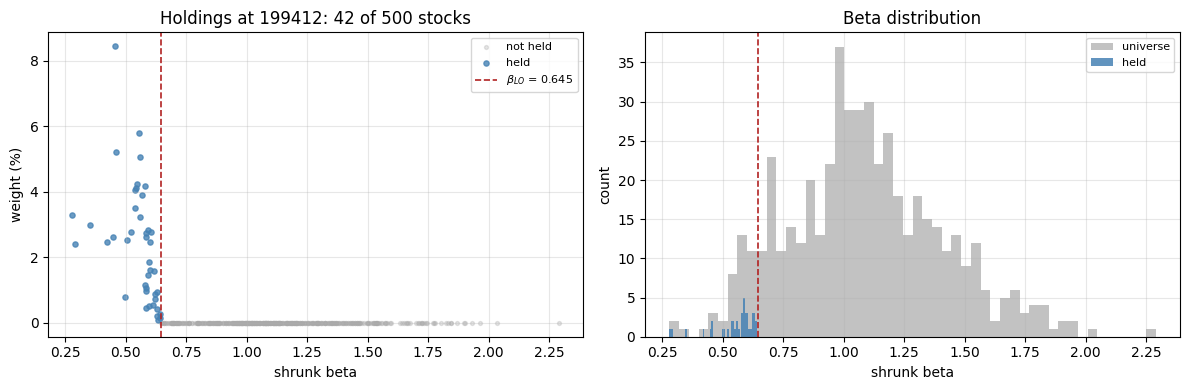

portfolio beta  = 0.523   (universe mean 1.088)
predicted vol   = 0.0747 annualised
largest holding = 8.45%


In [10]:
x_cf = res_cf["x"]
beta_LO = res_cf["beta_LO"]
held = x_cf > 0

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(cov.beta[~held], np.zeros((~held).sum()), s=8, alpha=0.3,
              color="darkgrey", label="not held")
ax[0].scatter(cov.beta[held], x_cf[held] * 100, s=14, alpha=0.8,
              color="steelblue", label="held")
ax[0].axvline(beta_LO, color="firebrick", ls="--", lw=1.2,
              label=f"$\\beta_{{LO}}$ = {beta_LO:.3f}")
ax[0].set_xlabel("shrunk beta"); ax[0].set_ylabel("weight (%)")
ax[0].set_title(f"Holdings at {t}: {held.sum()} of {len(universe)} stocks")
ax[0].legend(fontsize=8)

ax[1].hist(cov.beta, bins=50, color="darkgrey", alpha=0.7, label="universe")
ax[1].hist(cov.beta[held], bins=50, color="steelblue", alpha=0.85, label="held")
ax[1].axvline(beta_LO, color="firebrick", ls="--", lw=1.2)
ax[1].set_xlabel("shrunk beta"); ax[1].set_ylabel("count")
ax[1].set_title("Beta distribution"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"portfolio beta  = {cov.exante_beta(x_cf):.3f}   (universe mean {cov.beta.mean():.3f})")
print(f"predicted vol   = {cov.exante_vol(x_cf)*np.sqrt(12):.4f} annualised")
print(f"largest holding = {x_cf.max():.2%}")

### Record the out-of-sample month

In [11]:
r_next = rets.loc[t_next, universe]
missing = r_next.isna().sum()
r_next = r_next.fillna(float(rf.loc[t_next])).values

print(f"holdings with no return in {t_next}: {missing} "
      f"(their weight is assumed to earn the risk-free rate)")
print(f"minimum risk {t_next} return = {float(x_cf @ r_next):+.4%}")
print(f"  for reference, the universe mean that month = {float(r_next.mean()):+.4%}")

holdings with no return in 199501: 0 (their weight is assumed to earn the risk-free rate)
minimum risk 199501 return = +4.1668%
  for reference, the universe mean that month = +2.6204%


## 5. Full rolling backtest — satisfies step (c)

> *"In principle it would be sensible to estimate parameters and compute portfolios every
> month. However, you may choose to do it less frequently depending on your time
> constraints... This is a judgement call you will need to make."*

**We rebalance monthly.** The escape clause in the project is conditioned on time
constraints, and the analytic solution removes that constraint: the measured speedup
above makes the full 372-month backtest run in about a second, so there is no reason to
rebalance less often.

Two accounting decisions worth stating:

* **Delisting.** A holding with no return in month `t+1` has its weight earn the
  risk-free rate. Renormalising over the survivors instead would amount to knowing at the
  start of the month which stocks were about to disappear.
* **Turnover** is measured against the *drifted* weights of the previous month, so
  passive drift is not counted as trading.

In [12]:
t0 = time.time()
panel, weights = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                  start=idx[i_first], end=idx[i_last])
print(f"backtest finished in {time.time() - t0:.1f}s")
print(f"{panel.index.get_level_values('date').nunique()} out-of-sample months x "
      f"{panel.index.get_level_values('strategy').nunique()} strategies")
panel.head(6)

backtest finished in 1.4s
372 out-of-sample months x 1 strategies


,,ret,exret,pred_vol,exante_beta,n_held,beta_LO,eff_n,max_w,turnover
date,strategy,,,,,,,,,
199501,min_risk,0.0417,0.0375,0.0216,0.5230,42,0.6448,26.9241,0.0845,NaN
199502,min_risk,0.0261,0.0221,0.0205,0.5173,43,0.6423,26.4737,0.0890,0.1389
199503,min_risk,0.0099,0.0053,0.0207,0.5204,42,0.6406,26.1316,0.0824,0.0653
199504,min_risk,0.0129,0.0085,0.0209,0.5297,42,0.6431,25.2975,0.0868,0.0887
199505,min_risk,0.0589,0.0535,0.0201,0.5092,41,0.6301,24.7856,0.0984,0.0757
199506,min_risk,-0.0196,-0.0243,0.0192,0.4981,47,0.6378,26.7617,0.0734,0.1712


### Correctness checks

In [13]:
n_months = panel.index.get_level_values("date").nunique()
assert n_months == 372, f"expected 372 months, got {n_months}"

for name, w in weights.items():
    assert np.allclose(w.sum(axis=1), 1.0), f"{name}: weights do not sum to 1"
    assert (w.fillna(0) >= -1e-12).all().all(), f"{name}: negative weight found"

# Independently recompute a month's portfolio return from the stored weights and the
# raw return panel, to confirm the backtest's own accounting.
w_mr = weights["min_risk"]
for d in [w_mr.index[0], w_mr.index[len(w_mr) // 2], w_mr.index[-1]]:
    wd = w_mr.loc[d].dropna()
    nxt = idx[idx.get_loc(d) + 1]
    recomputed = float((wd * rets.loc[nxt, wd.index].fillna(rf.loc[nxt])).sum())
    assert np.isclose(panel.loc[(nxt, "min_risk"), "ret"], recomputed), f"mismatch at {nxt}"

# Out-of-sample returns must be untouched.
assert rets.max().max() > 20, "raw returns appear to have been modified"

print("all checks passed:")
print(f"  372 out-of-sample months")
print(f"  weights sum to 1 and are non-negative")
print(f"  portfolio returns reproduce an independent recomputation from stored weights")
print(f"  out-of-sample returns were not winsorised or clipped")

all checks passed:
  372 out-of-sample months
  weights sum to 1 and are non-negative
  portfolio returns reproduce an independent recomputation from stored weights
  out-of-sample returns were not winsorised or clipped


## 6. Summary statistics — satisfies step (d)

Sharpe ratios use excess returns; annualised return is geometric.
`pred_over_realized` divides the average predicted volatility by the realised one, and is
the diagnostic that says whether the covariance model knew what it was doing.

In [14]:
summary = summarize(panel)
summary.index = ["minimum risk"]
summary.round(4)

,ann_return,ann_vol,sharpe,max_drawdown,pred_over_realized,avg_n_held,avg_eff_n,ann_turnover
minimum risk,0.0820,0.1272,0.4992,-0.3755,0.5741,45.1156,25.3440,1.1662


In [15]:
mr = summary.loc["minimum risk"]
mr_panel = panel.xs("min_risk", level="strategy")
print(f"annualised return   {mr.ann_return:7.2%}")
print(f"annualised vol      {mr.ann_vol:7.2%}")
print(f"Sharpe ratio        {mr.sharpe:7.3f}")
print(f"max drawdown        {mr.max_drawdown:7.2%}")
print(f"\nholds {mr.avg_n_held:.0f} of {N} stocks on average "
      f"(effective N = {mr.avg_eff_n:.0f}), at an average beta of "
      f"{mr_panel.exante_beta.mean():.2f}")
print(f"annualised turnover {mr.ann_turnover:7.2%}")

annualised return     8.20%
annualised vol       12.72%
Sharpe ratio          0.499
max drawdown        -37.55%

holds 45 of 500 stocks on average (effective N = 25), at an average beta of 0.43
annualised turnover 116.62%


## 7. Cumulative return charts — satisfies step (d)

The left panel is the cumulative *sum* of excess returns: additive cumulation is easier to
read and makes a more sensible comparison than compounding, which visually rewards whichever
line happens to be the most volatile. The right panel shows drawdowns, which the summary
table reduces to a single number and which is where the path actually matters.

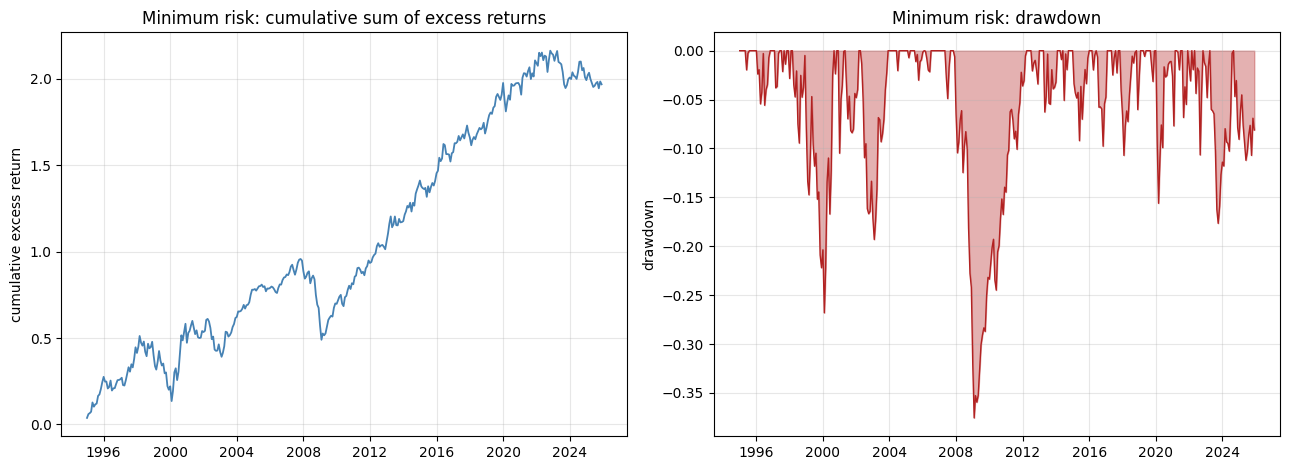

In [16]:
periods = pd.PeriodIndex([str(d) for d in mr_panel.index], freq="M").to_timestamp()
cum = (1 + mr_panel.ret.values).cumprod()
drawdown = cum / np.maximum.accumulate(cum) - 1.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(periods, mr_panel.exret.cumsum(), color="steelblue", lw=1.3)
ax[0].set_title("Minimum risk: cumulative sum of excess returns")
ax[0].set_ylabel("cumulative excess return")

ax[1].fill_between(periods, drawdown, 0, color="firebrick", alpha=0.35)
ax[1].plot(periods, drawdown, color="firebrick", lw=1)
ax[1].set_title("Minimum risk: drawdown"); ax[1].set_ylabel("drawdown")
plt.tight_layout(); plt.show()

## 8. Subperiods — satisfies the step (a) suggestion

> *"You may want to report results for different test periods that span different kinds of
> economic conditions."*

Decade buckets first, then the specific episodes. The episodes matter: a bucket running
1995-2007 would contain both the late-1990s bull market, where minimum risk lags badly,
and the 2000-2002 bust, where it does best — averaging the two hides the whole effect.

Episode returns are reported **cumulatively** rather than annualised, because a couple of
these windows are only two months long and annualising them yields figures that look
dramatic but carry no information.

In [17]:
def stats_for(mr_panel, lo, hi, label):
    g = mr_panel[(mr_panel.index >= lo) & (mr_panel.index <= hi)]
    vol = g.exret.std(ddof=1) * np.sqrt(12)
    return pd.Series(dict(
        months=len(g),
        ann_ret=(1 + g.ret.values).prod() ** (12 / len(g)) - 1,
        ann_vol=vol,
        sharpe=g.exret.mean() * 12 / vol,
        avg_n_held=g.n_held.mean(),
        avg_beta=g.exante_beta.mean(),
    ), name=label)

decades = [(199501, 199912, "1995-1999"), (200001, 200912, "2000-2009"),
           (201001, 201912, "2010-2019"), (202001, 202512, "2020-2025")]
pd.DataFrame([stats_for(mr_panel, lo, hi, lab) for lo, hi, lab in decades]).round(4)

,months,ann_ret,ann_vol,sharpe,avg_n_held,avg_beta
1995-1999,60.0000,0.0848,0.1308,0.3070,50.9833,0.4886
2000-2009,120.0000,0.0702,0.1340,0.3726,57.2583,0.3355
2010-2019,120.0000,0.1275,0.1052,1.1493,35.2333,0.4560
2020-2025,72.0000,0.0267,0.1448,0.0688,36.4583,0.4801


In [18]:
# Cumulative, not annualised: some of these windows are only a couple of months,
# and annualising them produces numbers that look dramatic but mean nothing.
def episode_stats(mr_panel, lo, hi, label):
    g = mr_panel[(mr_panel.index >= lo) & (mr_panel.index <= hi)]
    return pd.Series(dict(
        months=len(g),
        cum_ret=(1 + g.ret.values).prod() - 1,
        ann_vol=g.exret.std(ddof=1) * np.sqrt(12),
        avg_n_held=g.n_held.mean(),
    ), name=label)

episodes = [(200003, 200209, "dot-com bust 2000-02"), (200711, 200902, "GFC 2007-09"),
            (202002, 202003, "COVID crash 2020"),     (202201, 202212, "2022 drawdown")]
pd.DataFrame([episode_stats(mr_panel, lo, hi, lab) for lo, hi, lab in episodes]).round(4)

,months,cum_ret,ann_vol,avg_n_held
dot-com bust 2000-02,31.0000,0.4211,0.1865,54.1290
GFC 2007-09,16.0000,-0.3709,0.1507,53.0000
COVID crash 2020,2.0000,-0.1560,0.0682,38.0000
2022 drawdown,12.0000,0.0429,0.1664,34.5833


## 9. Diagnostics

### Predicted versus realised volatility

This is the sharpest result in the notebook, and it is a negative one.

A predicted-versus-realised ratio is only interpretable against a control: on its own, a
ratio of 0.57 could equally be a scaling or annualisation mistake. So we compare minimum
risk against two families of **random long-only portfolios** built from the same universe
and priced by the same covariance model:

* **diffuse** — random weights across all 500 stocks,
* **concentrated** — a random 45-stock subset, matching minimum risk's typical holding
  count, weighted by inverse residual variance.

The second control is the incisive one. If concentration alone caused the bias, the
concentrated random portfolios would be mispriced too. If they are not, then the problem
is not that minimum risk holds few stocks — it is *which* stocks the optimiser selects.

In [19]:
def make_random(seed, concentrated):
    # Each call draws a fresh portfolio, so over the backtest the constructor traces out
    # one series of randomly rebuilt portfolios priced by the same covariance model.
    rng = np.random.default_rng(seed)
    def construct(cov, **_):
        if concentrated:
            pick = rng.choice(cov.n, size=45, replace=False)
            w = np.zeros(cov.n)
            w[pick] = 1.0 / cov.omega2[pick]      # inverse residual variance, as min risk does
        else:
            w = rng.random(cov.n)
        w = w / w.sum()
        return dict(x=w, sigma2=cov.quad(w), n_held=int((w > 0).sum()))
    return construct

controls = {f"diffuse{j}": make_random(100 + j, False) for j in range(10)}
controls |= {f"conc{j}": make_random(200 + j, True) for j in range(10)}

diag_panel, _ = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                 start=idx[i_first], end=idx[i_last],
                                 constructors={"min_risk": min_risk_closed_form, **controls})

def ratio(df):
    return (df.pred_vol.mean() * np.sqrt(12)) / (df.exret.std(ddof=1) * np.sqrt(12))

strat = diag_panel.index.get_level_values("strategy")
rows = {
    "minimum risk": [ratio(diag_panel.xs("min_risk", level="strategy"))],
    "random, diffuse (500 names)": [ratio(diag_panel.xs(k, level="strategy")) for k in controls if k.startswith("diffuse")],
    "random, concentrated (45 names)": [ratio(diag_panel.xs(k, level="strategy")) for k in controls if k.startswith("conc")],
}
diag = pd.DataFrame({k: dict(n=len(v), mean_ratio=np.mean(v),
                             min_ratio=np.min(v), max_ratio=np.max(v))
                     for k, v in rows.items()}).T
print(diag.round(4).to_string())

mr_ratio = rows["minimum risk"][0]
conc_lo = min(rows["random, concentrated (45 names)"])
print(f"\nthe model captures {mr_ratio:.0%} of minimum risk's realised volatility")
print(f"but {np.mean(rows['random, diffuse (500 names)']):.0%} for diffuse random portfolios "
      f"and {np.mean(rows['random, concentrated (45 names)']):.0%} for equally concentrated "
      f"random ones")
assert mr_ratio < conc_lo, "minimum risk is not distinguishable from random concentration"
print("\nconcentration alone does not explain the bias: random 45-stock portfolios are")
print("priced correctly, while minimum risk is not. The problem is the selection.")

                                      n  mean_ratio  min_ratio  max_ratio
minimum risk                     1.0000      0.5741     0.5741     0.5741
random, diffuse (500 names)     10.0000      0.9688     0.9650     0.9732
random, concentrated (45 names) 10.0000      0.9740     0.9489     0.9932

the model captures 57% of minimum risk's realised volatility
but 97% for diffuse random portfolios and 97% for equally concentrated random ones

concentration alone does not explain the bias: random 45-stock portfolios are
priced correctly, while minimum risk is not. The problem is the selection.


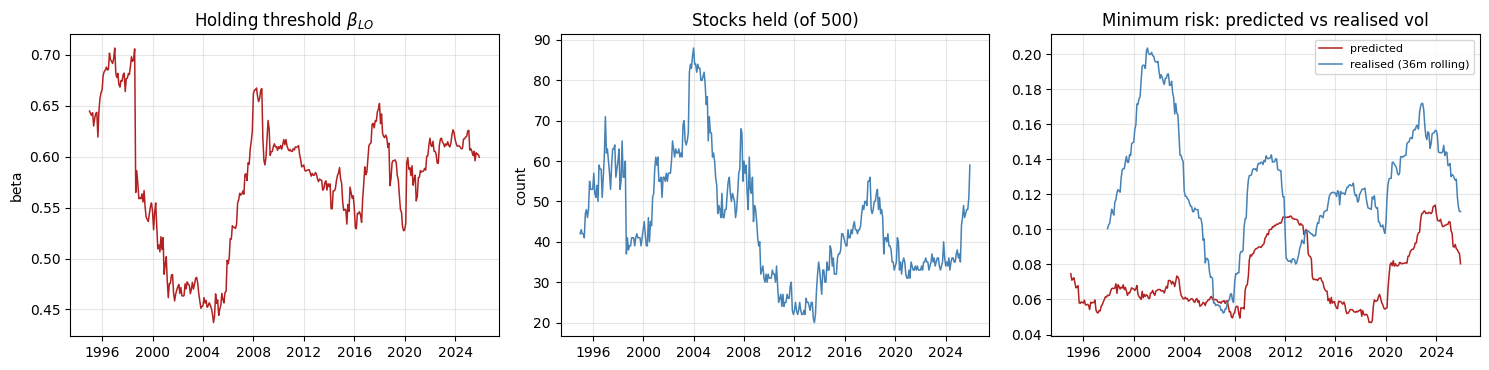

beta_LO    : mean 0.578, range [0.437, 0.707]
stocks held: mean 45, range [20, 88]
ex-ante beta: mean 0.427


In [20]:
mr_periods = pd.PeriodIndex([str(d) for d in mr_panel.index], freq="M").to_timestamp()
roll = mr_panel.exret.rolling(36).std() * np.sqrt(12)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(mr_periods, mr_panel.beta_LO, color="firebrick", lw=1.1)
ax[0].set_title("Holding threshold $\\beta_{LO}$"); ax[0].set_ylabel("beta")

ax[1].plot(mr_periods, mr_panel.n_held, color="steelblue", lw=1.1)
ax[1].set_title(f"Stocks held (of {N})"); ax[1].set_ylabel("count")

ax[2].plot(mr_periods, mr_panel.pred_vol * np.sqrt(12), label="predicted", color="firebrick", lw=1.1)
ax[2].plot(mr_periods, roll, label="realised (36m rolling)", color="steelblue", lw=1.1)
ax[2].set_title("Minimum risk: predicted vs realised vol"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"beta_LO    : mean {mr_panel.beta_LO.mean():.3f}, "
      f"range [{mr_panel.beta_LO.min():.3f}, {mr_panel.beta_LO.max():.3f}]")
print(f"stocks held: mean {mr_panel.n_held.mean():.0f}, "
      f"range [{mr_panel.n_held.min()}, {mr_panel.n_held.max()}]")
print(f"ex-ante beta: mean {mr_panel.exante_beta.mean():.3f}")

## Summary

* Minimum risk brings annualised volatility down to about **12.7%** and cuts the maximum
  drawdown materially, which is what it is built to do.
* It gets there by holding roughly **45 of 500 stocks** at an average beta near **0.43** —
  under a single-factor covariance, "minimum risk" is structurally a low-beta bet, exactly
  as the analytic solution says.
* It is strongly **regime dependent**: it lags badly through the late-1990s bull market and
  gains sharply through the 2000-02 bust and 2022. Any subperiod split that merges those
  windows will cancel the effect out.
* The covariance model **underestimates minimum risk's volatility by roughly a factor of
  two**, while pricing both diffuse and equally concentrated *random* portfolios correctly.
  Concentration is therefore not the cause — the optimiser's selection is. This is the
  uncorrelated-residual assumption failing, and it is the strongest argument in this
  notebook for either a richer covariance model or a position limit.

### Not covered here

The equally weighted and value weighted benchmarks required for the project's comparison
are produced separately. Also out of scope: maximum diversification, risk parity and HRP;
alternative covariance estimators; position caps, transaction costs and factor attribution.